# Лабораторна робота 1 — Дослідження даних з NumPy, Pandas та scikit-learn

**Набір даних:** `kc_house_data.csv`  
**Дозволені бібліотеки:** NumPy, Pandas, Matplotlib, scikit-learn (усі модулі)

## Налаштування — встановлення залежностей та імпорт

Запустіть комірку нижче один раз, щоб переконатись, що всі необхідні пакети встановлені.

In [9]:
# Встановлення залежностей (можна запускати повторно)
import sys
!{sys.executable} -m pip install numpy pandas matplotlib scikit-learn --quiet


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)


---
## Завдання 1 — Розминка з NumPy

**а)** Створіть масив NumPy з 10 000 значень, що підпорядковані нормальному розподілу N(0, 1). Обчисліть середнє, стандартне відхилення, мінімум і максимум за допомогою функцій NumPy — **без Python-циклів**.

**б)** Підрахуйте, скільки значень виходять за межі ±2 стандартних відхилення, використовуючи логічну індексацію. Яка це відсоткова частка? Порівняйте з теоретичним значенням ≈4,55 %.

In [3]:
import numpy as np

array = np.random.normal(0, 1, 10000)
# Завдання 1а — створіть масив і обчисліть статистику
max = np.max(array)
min = np.min(array)
mean = np.mean(array)
std = np.std(array)
print(f"Max: {max}, Min: {min}, Mean: {mean}, Std: {std}")

Max: 3.535335376715148, Min: -3.8652882562523656, Mean: 0.005052847277800701, Std: 1.003010654602342


In [17]:
positive_mask = array > 2
negative_mask = array < -2
elements = len(array[positive_mask | negative_mask])
fraction = elements / len(array)
print(f"Elements greater than 2 or less than -2: {elements}")
print(f"Fraction of outliers: {fraction}")
print(f"Empirical to theoretical ratio: {fraction/0.0455}")

Elements greater than 2 or less than -2: 414
Fraction of outliers: 0.0414
Empirical to theoretical ratio: 0.9098901098901099


Відповідь (б):
Elements greater than 2 or less than -2: 496
Fraction of outliers: 0.0496
Empirical to theoretical ratio: 1.09010989010989

---
## Завдання 2 — Завантаження та огляд набору даних

Завантажте `kc_house_data.csv` у Pandas DataFrame та дайте відповідь на питання нижче, написавши код:

1. Скільки рядків і стовпців у наборі даних?
2. Які мінімум, максимум, середнє та медіана цін на будинки?
3. Скільки унікальних поштових індексів є у наборі даних? Який поштовий індекс має найбільше оголошень?

In [2]:
# Завантаження набору даних
sales = pd.read_csv('kc_house_data.csv')
sales.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [28]:
# 2-і) Скільки рядків і стовпців?
print(f"Number of rows: {sales.shape[0]}, Number of columns: {sales.shape[1]}")



Number of rows: 21613, Number of columns: 21


In [29]:
# 2-іі) Мінімум, максимум, середнє та медіана ціни
prices = sales['price']
print(f"Min price: {prices.min()}")
print(f"Max price: {prices.max ()}")
print(f"Mean price: {prices.mean()}")
print(f"Median price: {prices.median()}")


Min price: 75000.0
Max price: 7700000.0
Mean price: 540088.1417665294
Median price: 450000.0


In [30]:
# 2-ііі) Кількість унікальних поштових індексів; індекс з найбільшою кількістю оголошень
zipcodes = sales['zipcode']
print(f"Unique zipcodes: {zipcodes.nunique()}")
print(f"Most common zipcode: {zipcodes.mode()[0]}")

Unique zipcodes: 70
Most common zipcode: 98103


---
## Завдання 3 — Візуалізація даних

Створіть **два графіки поруч**:

- **Лівий:** гістограма `price` (50 інтервалів, логарифмічна шкала по осі X).
- **Правий:** діаграма розсіювання `sqft_living` vs `price`, де кольором точок позначено `bedrooms`. Додайте підписи осей і colorbar.

Одним реченням для кожного графіка опишіть, що ви спостерігаєте.

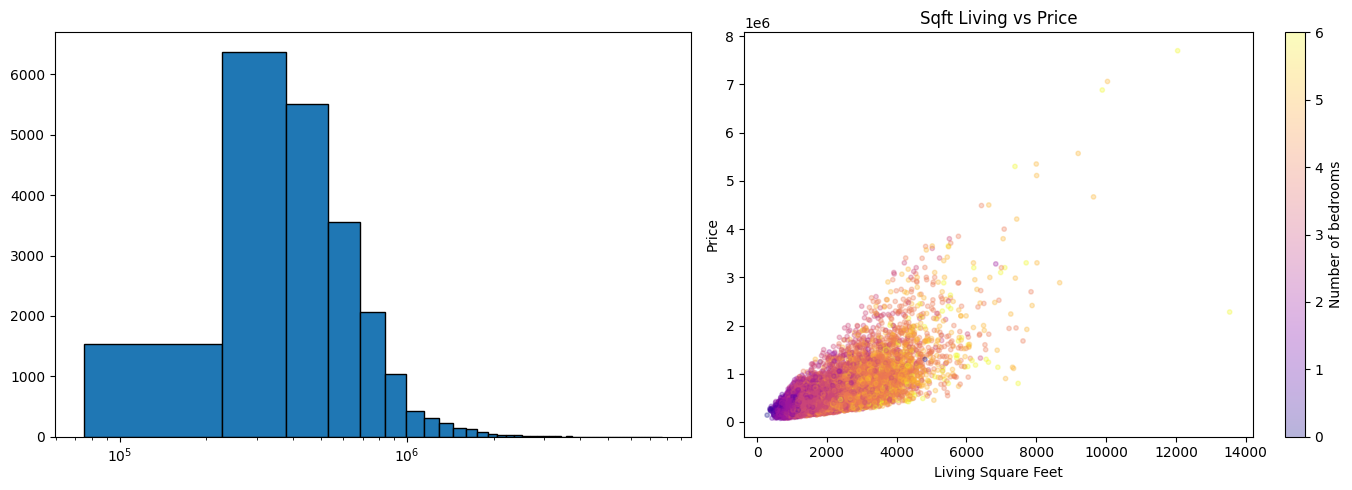

In [3]:
from turtle import color

from matplotlib.pyplot import scatter


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Завдання 3 — лівий графік: гістограма ціни
plt.subplot(1, 2, 1)
plt.hist(sales['price'], bins=50, edgecolor='black')
plt.xscale('log')

# Завдання 3 — правий графік: діаграма розсіювання sqft_living vs price
plt.subplot(1, 2, 2)  
scatter = plt.scatter(sales['sqft_living'], sales['price'], vmax=6, cmap='plasma', c = sales['bedrooms'], alpha=0.3, s=10)
plt.colorbar(scatter, label='Number of bedrooms')

plt.title('Sqft Living vs Price')
plt.xlabel('Living Square Feet')
plt.ylabel('Price')

plt.tight_layout()
plt.show()


**Спостереження (лівий графік):** *Бачимо, що більшість квартир мають вартість менше 10^6, при цьому після медіаного значення графік йде на спад і в другій своїй половині набуває приблизно нульових значеннь*

**Спостереження (правий графік):** *Бачимо, що більшість квартир має плошу меншу за 6000 з малою ціною. Помітно, що при збільшенні площі квартири зростає кількість спальних кімнат в ній.*

---
## Завдання 4 — Навчання та оцінка регресійної моделі

Розбийте дані 80/20 (`random_state=42`). Навчіть `LinearRegression` з scikit-learn для передбачення `price` за єдиною ознакою `sqft_living`.

1. Вкажіть вільний член (intercept) та коефіцієнт для `sqft_living`.
2. Обчисліть MSE і RMSE на тестовій вибірці.
3. Яка передбачувана ціна будинку площею 2 500 кв. футів?

In [8]:
# Поділ на навчальну та тестову вибірки
train_data, test_data = train_test_split(sales, test_size=0.2, random_state=42)


In [12]:
# Завдання 4 — навчіть модель, вкажіть ваги, обчисліть MSE/RMSE, передбачте ціну для 2500 кв. фут.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
model = LinearRegression().fit(
    train_data[['sqft_living']], train_data['price'])
print(f"Coefficient: {model.coef_[0]}, Intercept: {model.intercept_}")
mse_value = mean_squared_error(test_data['price'], model.predict(test_data[['sqft_living']]))
print(f"MSE: {mse_value:,.2f}")
rmse_value = np.sqrt(mse_value)
print(f"RMSE: {rmse_value:,.2f}")
house_to_predict = pd.DataFrame({'sqft_living': [2500]})
predicted_price = model.predict(house_to_predict)
print(f"Predicted price for 2500 sqft: {predicted_price[0]}")

Coefficient: 279.5547793152631, Intercept: -41999.1860399358
MSE: 76,484,977,061.78
RMSE: 276,559.17
Predicted price for 2500 sqft: 656887.7622482219


---
## Завдання 5 — Порівняння двох моделей

Навчіть другу `LinearRegression` з ознаками: `sqft_living`, `bedrooms`, `bathrooms`, `yr_built`. Порівняйте RMSE на тестовій вибірці між Моделлю 1 та Моделлю 2. Яке значення нижче? Коротко поясніть чому.

In [10]:
# Завдання 5 — модель з чотирма ознаками та порівняння RMSE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
model_multi = LinearRegression().fit(
    train_data[['sqft_living', 'bedrooms', 'bathrooms', 'yr_built']], train_data['price'])
rmse = np.sqrt(mean_squared_error(test_data['price'], model_multi.predict(test_data[['sqft_living', 'bedrooms', 'bathrooms', 'yr_built']])))
print(f"RMSE for multi-feature model: {rmse:,.2f}")

RMSE for multi-feature model: 262,985.98


**Відповідь:** *Для моделі з багатьма ознаками rmse, так як модель враховує більше параметрів та є більш точною *

---
## ✨ Бонус — Аналіз залишків

Для вашої кращої моделі обчисліть вектор залишків (predicted − actual). Побудуйте гістограму. Чи виглядають залишки нормально розподіленими та центрованими навколо нуля? Що означав би систематичний ненульовий середній залишок?

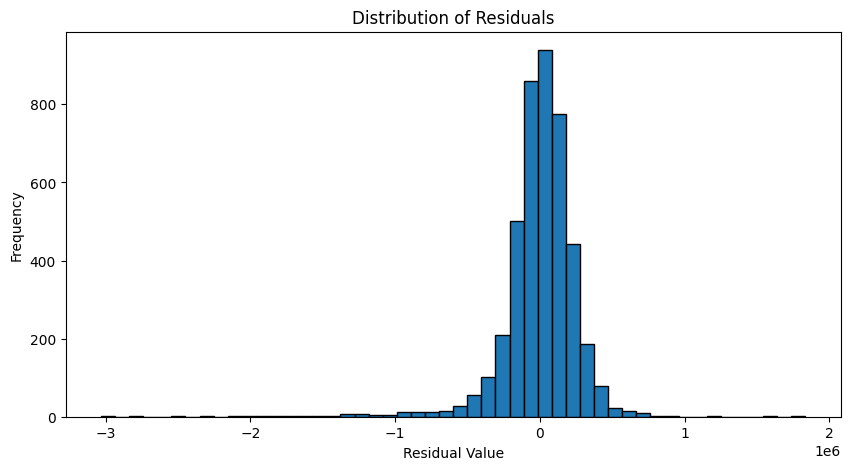

In [24]:
# Бонус — аналіз залишків
# 1. Отримуємо передбачення для найкращої моделі
predictions_multi = model_multi.predict(test_data[['sqft_living', 'bedrooms', 'bathrooms', 'yr_built']])

# 2. Обчислюємо вектор залишків (як ви і просили: predicted - actual)
residuals = predictions_multi - test_data['price']

from matplotlib.pyplot import scatter

plt.figure(figsize=(10, 5))
hist = plt.hist(residuals, bins=50, edgecolor='black')
plt.title('Distribution of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.show()



**Спостереження:** *З графіка видно, що дані виглядають нормально розподіленими та центровані відносно нуля.
Систематичний ненульовий середній залишок означав би що модель систематично завищує (якщо Середнє > 0) або занижує (Середнє < 0) ціну на будинки*